# L4b Advanced: From the Binomial Lattice to Geometric Brownian Motion

The L4b lecture opened by promising that a lattice with the right scaling converges to a continuous model, and that the model is geometric Brownian motion. This notebook keeps that promise. We choose the binomial up and down factors and the up probability so that each lattice step matches the mean of a GBM growth-rate step exactly and its variance up to a term of second order in the step, and then we let the number of steps grow with the horizon fixed. The terminal lattice distribution converges to the lognormal, and the L4a binomial-tail target probability converges to the L4b closed form.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Calibrate a lattice to GBM parameters:** Choose the up factor, down factor, and up probability from the drift and volatility so that one lattice step reproduces the mean and variance of a one-step GBM growth rate.
> - **Watch the terminal distribution converge:** Explain why the terminal log price of the calibrated lattice tends to a normal distribution as the step count grows, and see the lattice mass approach the lognormal density.
> - **Reconcile the two target probabilities:** Show that the L4a binomial tail for a strict target converges to the L4b standard normal formula, and quantify the discretization error as a function of the number of steps.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the constant-parameter GBM of the lecture and the recombining binomial lattice of L3b and L4a. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the binomial and normal distributions, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, and [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. Match one lattice step to one GBM step

Fix the GBM parameters $\mu$ (arithmetic drift), $\sigma$ (volatility), and a horizon $T$ (years), and write $\bar g=\mu-\sigma^{2}/2$ for the mean growth rate. Under GBM, the log return over a step of length $\Delta t$ is normal with mean $\bar g\,\Delta t$ and variance $\sigma^{2}\Delta t$. A binomial lattice step multiplies the price by $u$ with probability $p$ or by $d$ with probability $1-p$, so its log return is $\ln u$ or $\ln d$. The symmetric choice
$$
u=e^{\sigma\sqrt{\Delta t}},\qquad d=e^{-\sigma\sqrt{\Delta t}}=1/u,\qquad p=\frac{1}{2}\left(1+\frac{\bar g}{\sigma}\sqrt{\Delta t}\right)
$$
gives a log return of $\pm\sigma\sqrt{\Delta t}$ with mean $\sigma\sqrt{\Delta t}\,(2p-1)=\bar g\,\Delta t$, exactly the GBM mean, and variance $\sigma^{2}\Delta t-(\bar g\,\Delta t)^{2}$, which is the GBM variance up to a term of order $\Delta t^{2}$. This is the Cox, Ross, and Rubinstein parameterization of the up and down factors; we use it here with the real-world probability $p$, and later in the course (L9a) with a risk-neutral probability in its place. The probability $p$ is a valid probability whenever $|\bar g/\sigma|\sqrt{\Delta t}<1$, which holds for any reasonable step.

Let's fix the parameters. The drift and volatility are typical of the S&P 500 estimates in the L4b example, the horizon is one year, and the benchmark rate and target are the ones we will use for the target probability in Section 3:

In [3]:
S₀ = 100.0      # initial share price (USD/share)
μ = 0.15        # arithmetic GBM drift (1/years)
σ = 0.30        # GBM volatility (1/sqrt(years))
T = 1.0         # horizon (years)
g_b = 0.05      # benchmark growth rate (1/years), continuously compounded
ρ_star = 0.10   # target scaled NPV ρ⋆ (dimensionless)
ḡ = μ - 0.5*σ^2 # mean growth rate ḡ (1/years)

@assert σ > 0 && T > 0 && ρ_star > -1
(S₀ = S₀, μ = μ, σ = σ, T = T, g_b = g_b, ρ_star = ρ_star, ḡ = ḡ)

(S₀ = 100.0, μ = 0.15, σ = 0.3, T = 1.0, g_b = 0.05, ρ_star = 0.1, ḡ = 0.105)

Next, let's write a function that builds the calibrated lattice for $N$ steps over the horizon $T$, and returns the factors, the up probability, and the step length. We also compute the exact mean and variance of one lattice log-return step so we can compare them with the GBM values:

In [4]:
function lattice_from_gbm(μ::Real, σ::Real, T::Real, N::Int)
    @assert N >= 1
    Δt = T/N
    ḡ = μ - 0.5*σ^2
    u = exp(σ*sqrt(Δt))
    d = 1/u
    p = 0.5*(1 + (ḡ/σ)*sqrt(Δt))
    @assert 0 < p < 1 "the step is too coarse for a valid up probability"
    step_mean = p*log(u) + (1-p)*log(d)               # exact mean of one lattice log-return step
    step_variance = p*log(u)^2 + (1-p)*log(d)^2 - step_mean^2 # exact variance of one lattice log-return step
    return (u = u, d = d, p = p, Δt = Δt, step_mean = step_mean, step_variance = step_variance)
end

lattice_from_gbm(μ, σ, T, 252)

(u = 1.0190779253080744, d = 0.9812792281784467, p = 0.5110239637961025, Δt = 0.003968253968253968, step_mean = 0.0004166666666666711, step_variance = 0.0003569692460317463)

Do the moments match? Let's tabulate the lattice step mean and variance against the GBM values $\bar g\,\Delta t$ and $\sigma^{2}\Delta t$ for a range of step counts, together with the up probability, in the `moment_table::DataFrame` variable. Watch the variance ratio approach one as $\Delta t$ shrinks:

In [5]:
moment_table = let
    df = DataFrame(N = Int[], Δt = Float64[], p = Float64[],
        lattice_mean = Float64[], gbm_mean = Float64[], var_ratio = Float64[])
    for N ∈ (4, 16, 64, 252, 1008)
        lat = lattice_from_gbm(μ, σ, T, N)
        push!(df, (N, lat.Δt, lat.p, lat.step_mean, ḡ*lat.Δt, lat.step_variance/(σ^2*lat.Δt)))
    end
    df
end
pretty_table(moment_table; formatters = [fmt__printf("%.6f", [2,3,4,5,6])])

┌───────┬──────────┬──────────┬──────────────┬──────────┬───────────┐
│     N │       Δt │        p │ lattice_mean │ gbm_mean │ var_ratio │
│ Int64 │  Float64 │  Float64 │      Float64 │  Float64 │   Float64 │
├───────┼──────────┼──────────┼──────────────┼──────────┼───────────┤
│     4 │ 0.250000 │ 0.587500 │     0.026250 │ 0.026250 │  0.969375 │
│    16 │ 0.062500 │ 0.543750 │     0.006562 │ 0.006562 │  0.992344 │
│    64 │ 0.015625 │ 0.521875 │     0.001641 │ 0.001641 │  0.998086 │
│   252 │ 0.003968 │ 0.511024 │     0.000417 │ 0.000417 │  0.999514 │
│  1008 │ 0.000992 │ 0.505512 │     0.000104 │ 0.000104 │  0.999878 │
└───────┴──────────┴──────────┴──────────────┴──────────┴───────────┘


The means agree exactly at every $N$, as they must by construction, and the variance ratio $1-(\bar g/\sigma)^{2}\Delta t$ tends to one. One calibrated step is therefore a two-point stand-in for a Gaussian growth-rate step whose mean is right and whose variance becomes right in the limit.

___

## 2. The terminal distribution converges to the lognormal

Over $N$ steps the terminal log price ratio is a sum of $N$ independent lattice log returns:
$$
\ln\frac{S_{T}}{S_{0}}=\sum_{j=1}^{N}\pm\sigma\sqrt{\Delta t}=\sigma\sqrt{\Delta t}\,\bigl(2K_{N}-N\bigr),\qquad K_{N}\sim\texttt{Binomial}(N,p),
$$
where $K_{N}$ counts the up moves, exactly as in L4a. Its mean is $N\bar g\,\Delta t=\bar g\,T$ for every $N$, and its variance is $N\sigma^{2}\Delta t\,[1-(\bar g/\sigma)^{2}\Delta t]\to\sigma^{2}T$. The central limit theorem then says that the standardized sum tends to a standard normal, so $\ln(S_{T}/S_{0})$ tends in distribution to $\mathcal{N}(\bar g\,T,\sigma^{2}T)$, which is exactly the GBM law from the lecture, and $S_{T}$ tends to the lognormal.

To see it, we convert the lattice probability mass at each terminal node into a density by dividing by the spacing $2\sigma\sqrt{\Delta t}$ between neighboring terminal log prices, and overlay the normal density. Let's compute the terminal nodes and their probabilities for several step counts:

In [6]:
function terminal_lattice_density(μ::Real, σ::Real, T::Real, N::Int)
    lat = lattice_from_gbm(μ, σ, T, N)
    K = Binomial(N, lat.p)
    x = [σ*sqrt(lat.Δt)*(2k - N) for k ∈ 0:N]   # terminal log price ratio at each node
    mass = [pdf(K, k) for k ∈ 0:N]               # binomial node probability
    density = mass ./ (2σ*sqrt(lat.Δt))          # probability mass per unit log price
    return (x = x, mass = mass, density = density)
end

terminal_normal = Normal(ḡ*T, σ*sqrt(T)) # GBM law of ln(S_T/S_0)
step_counts = (4, 16, 64, 252)
lattice_densities = Dict(N => terminal_lattice_density(μ, σ, T, N) for N ∈ step_counts);
@assert all(isapprox(sum(lattice_densities[N].mass), 1.0; atol=1e-12) for N ∈ step_counts)

Now let's plot the lattice density (points) against the GBM normal density (curve) for each step count. The horizontal axis is the terminal log price ratio; the same picture in price space is the lognormal:

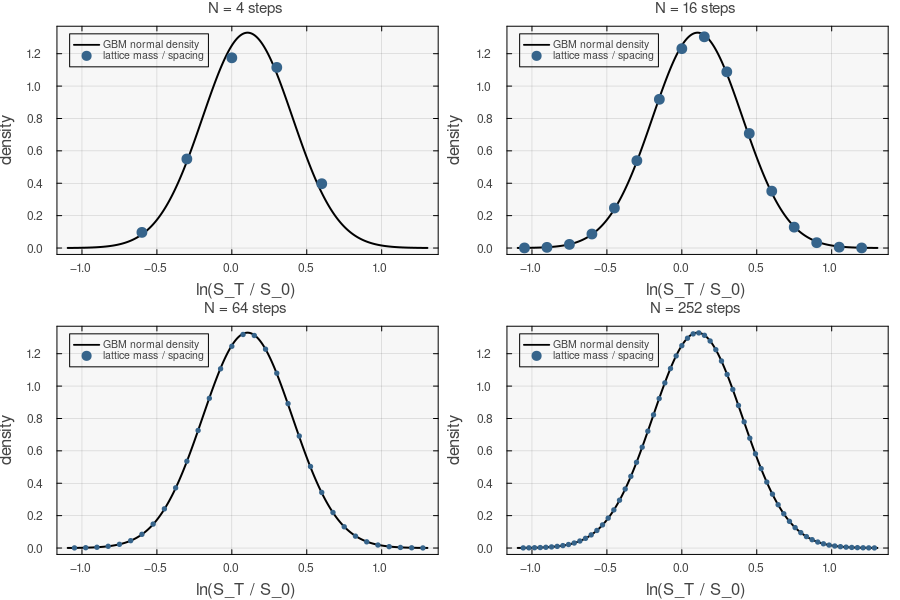

In [7]:
let
    xgrid = range(ḡ*T - 4σ*sqrt(T), ḡ*T + 4σ*sqrt(T), length = 400)
    panels = []
    for N ∈ step_counts
        d = lattice_densities[N]
        keep = (d.x .>= first(xgrid)) .& (d.x .<= last(xgrid))
        p = plot(xgrid, pdf.(terminal_normal, xgrid); color = :black, label = "GBM normal density",
            title = "N = $(N) steps", titlefontsize = 10, xlabel = "ln(S_T / S_0)", ylabel = "density")
        scatter!(p, d.x[keep], d.density[keep]; color = :steelblue4, markersize = (N <= 16 ? 6 : 3),
            markerstrokewidth = 0, label = "lattice mass / spacing")
        push!(panels, p)
    end
    plot(panels...; layout = (2, 2), size = (900, 600), legend = :topleft, legendfontsize = 7)
end

With four steps the lattice is five spikes; with 252 steps (daily over a year) it is indistinguishable from the normal curve. Two things did the work: the calibrated $u$, $d$, and $p$ made every step's mean and variance right, and independence across steps let the central limit theorem turn the sum into a Gaussian. Neither ingredient is optional. A finer lattice with badly scaled factors converges to something else, or to nothing.

___

## 3. The L4a binomial tail converges to the L4b closed form

L4a computed the probability that a scheduled long position clears a strict target $\rho_{\star}$ as a binomial tail: solve for the smallest up count $k_{\min}$ that clears the target and sum the binomial probabilities from $k_{\min}$ to $N$. L4b computed the same probability under GBM as $1-\Phi(z)$ with $z=[\ln(1+\rho_{\star})+g_bT-\bar g\,T]/(\sigma\sqrt{T})$. On the calibrated lattice the first must converge to the second. Let's implement both, following the L4a and L4b lectures exactly:

In [8]:
function lattice_target_probability(u::Real, d::Real, p::Real, N::Int, g_b::Real, T::Real, ρ_star::Real)
    τ = (log(1 + ρ_star) + g_b*T - N*log(d))/log(u/d) # real-valued count threshold (L4a)
    k_min = floor(Int, τ) + 1                          # first successful up count
    k_min <= 0 && return 1.0                           # every terminal node succeeds
    k_min > N && return 0.0                            # no terminal node succeeds
    return ccdf(Binomial(N, p), k_min - 1)             # P(K_N >= k_min)
end

gbm_target_probability(μ::Real, σ::Real, T::Real, g_b::Real, ρ_star::Real) =
    1 - cdf(Normal(), (log(1 + ρ_star) + g_b*T - (μ - 0.5*σ^2)*T)/(σ*sqrt(T))) # L4b closed form

p_gbm = gbm_target_probability(μ, σ, T, g_b, ρ_star)
println("GBM closed form: P(ρ_T > $(ρ_star)) = $(round(p_gbm, digits = 6))")

GBM closed form: P(ρ_T > 0.1) = 0.446556


Now let's evaluate the lattice tail for step counts from 4 to 4032 and tabulate the absolute error against the closed form in the `convergence_table::DataFrame` variable:

In [9]:
convergence_table = let
    df = DataFrame(N = Int[], lattice_probability = Float64[], gbm_probability = Float64[], abs_error = Float64[])
    for N ∈ (4, 8, 16, 32, 64, 128, 252, 504, 1008, 2016, 4032)
        lat = lattice_from_gbm(μ, σ, T, N)
        p_lat = lattice_target_probability(lat.u, lat.d, lat.p, N, g_b, T, ρ_star)
        push!(df, (N, p_lat, p_gbm, abs(p_lat - p_gbm)))
    end
    df
end
pretty_table(convergence_table; formatters = [fmt__printf("%.6f", [2,3,4])])

┌───────┬─────────────────────┬─────────────────┬───────────┐
│     N │ lattice_probability │ gbm_probability │ abs_error │
│ Int64 │             Float64 │         Float64 │   Float64 │
├───────┼─────────────────────┼─────────────────┼───────────┤
│     4 │            0.453719 │        0.446556 │  0.007163 │
│     8 │            0.504756 │        0.446556 │  0.058200 │
│    16 │            0.542709 │        0.446556 │  0.096153 │
│    32 │            0.429906 │        0.446556 │  0.016650 │
│    64 │            0.490764 │        0.446556 │  0.044207 │
│   128 │            0.463739 │        0.446556 │  0.017183 │
│   252 │            0.463949 │        0.446556 │  0.017393 │
│   504 │            0.444430 │        0.446556 │  0.002126 │
│  1008 │            0.451315 │        0.446556 │  0.004759 │
│  2016 │            0.453173 │        0.446556 │  0.006617 │
│  4032 │            0.445051 │        0.446556 │  0.001505 │
└───────┴─────────────────────┴─────────────────┴───────────┘


The error shrinks but not monotonically. Let's plot it on log axes, together with an envelope proportional to $1/\sqrt{N}$ (anchored to the largest scaled error):

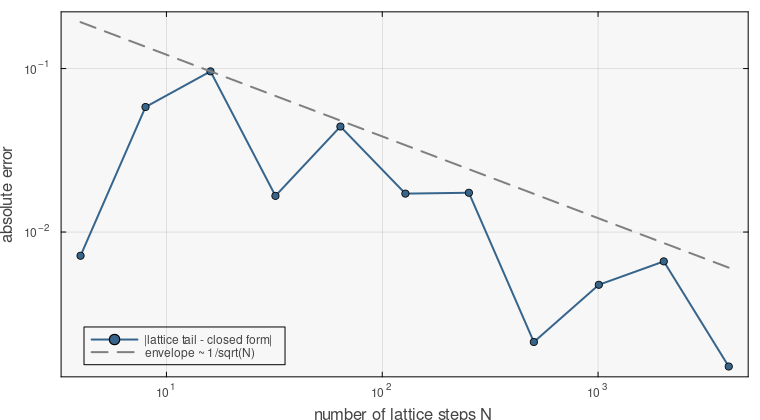

In [10]:
let
    Ns = convergence_table.N
    err = convergence_table.abs_error
    plot(Ns, err; xscale = :log10, yscale = :log10, marker = :circle, color = :steelblue4,
        label = "|lattice tail - closed form|", xlabel = "number of lattice steps N",
        ylabel = "absolute error", size = (760, 420), legend = :bottomleft)
    C_env = maximum(err .* sqrt.(Ns)) # envelope constant
    plot!(Ns, C_env ./ sqrt.(Ns); color = :gray50, linestyle = :dash, label = "envelope ~ 1/sqrt(N)")
end

The central limit theorem puts the convergence rate at order $1/\sqrt{N}$ (the dashed line is that rate drawn through the worst point, a bound rather than a fit), and the errors fall broadly in line with it but not monotonically: there is a saw-tooth on top. The saw-tooth is the integer boundary from L4a: as $N$ changes, the target $\rho_{\star}$ falls at different positions between neighboring terminal nodes, and the strict tail jumps whenever a node crosses the target. That is a discretization artifact of the lattice, not a property of the trade, and it is one reason the continuous model is convenient: its answer moves smoothly with the target.

___

## Summary

This notebook connected the two halves of week 4. A binomial lattice whose factors and probability are matched to the drift and volatility of GBM has terminal distributions that converge to the lognormal, and its binomial-tail target probability converges to the standard normal formula of the lecture.

> __Key Takeaways:__
>
> - **Calibration is a moment match:** Choosing the up factor as the exponential of the volatility times the square root of the step, its reciprocal as the down factor, and an up probability tilted by the mean growth rate makes each lattice step reproduce the mean and, in the limit, the variance of a GBM growth-rate step.
> - **The limit is the central limit theorem:** The terminal log price is a sum of independent matched steps, so it becomes Gaussian as the step count grows, which is exactly the GBM law.
> - **The two target probabilities agree in the limit:** The L4a binomial tail approaches the L4b closed form at roughly the inverse square root of the step count, with a saw-tooth from the integer up-count boundary that the continuous model does not have.

The same up and down factors return in L9a, where a risk-neutral probability replaces the real-world one and the lattice prices derivatives instead of forecasting them.

___

## Disclaimer and Risks

This notebook is for instruction only. Lattice and GBM probabilities depend on the assumed parameters, which are estimated with error, and on a frictionless scheduled trade. This material is not investment or trading advice.

___